Loading B2B synthetic delivery data...
Engineering B2B specific features...

Generating EDA Visualizations...


C:\Users\93189\AppData\Local\Temp\ipykernel_16336\2680134964.py:81: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0, 1].set_xticklabels(['On Time/Early', 'Gray Area (In Grace)', 'Contract Breach'])


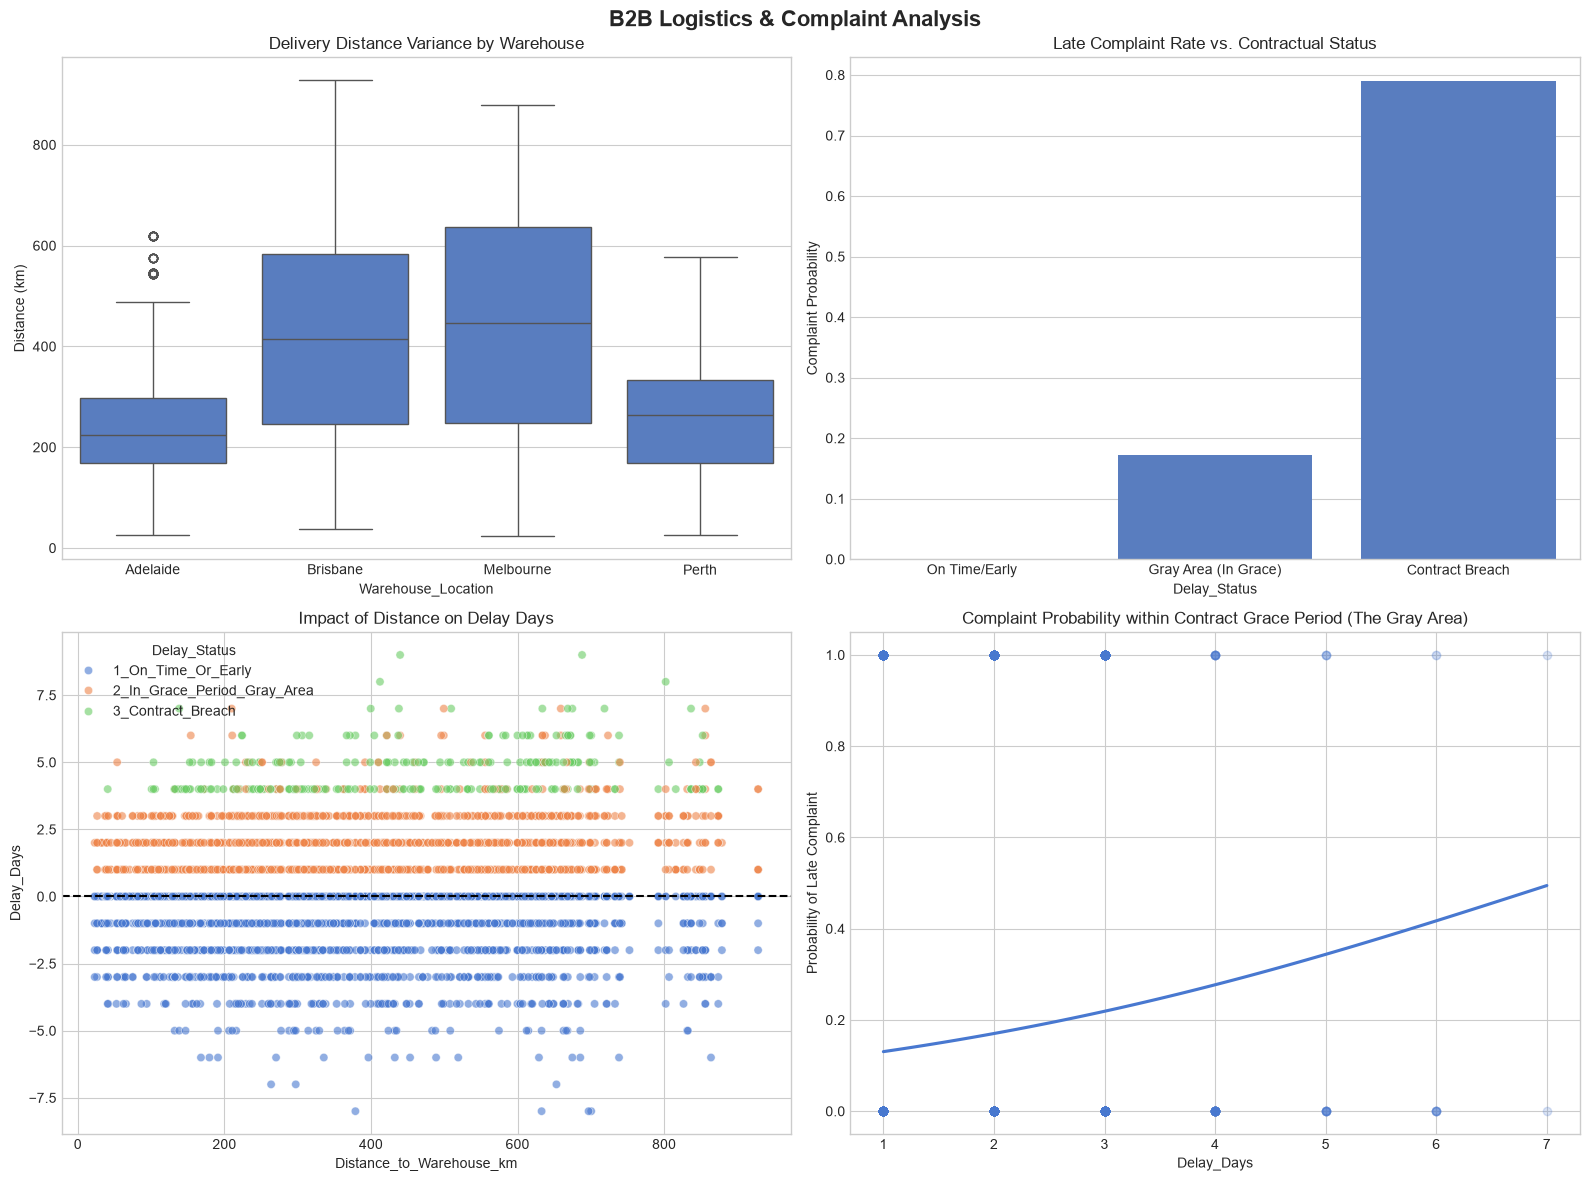


--- Final Processed Data Snapshot ---
     Order_ID Customer_ID  Distance_to_Warehouse_km  \
0  ORD-100000   B2B-33392                    172.39   
1  ORD-100001   B2B-83887                     45.19   
2  ORD-100002   B2B-41706                     65.65   
3  ORD-100003   B2B-28602                    223.10   
4  ORD-100004   B2B-34949                    297.34   

   Contract_Grace_Period_Days  Lead_Time_Allowed  Is_Weekend_Deadline  \
0                           7                  7                    0   
1                           7                  9                    1   
2                           7                 14                    0   
3                           3                 11                    0   
4                           3                 14                    0   

   Shipping_Cost  Delay_Days  Days_Beyond_Grace  Is_Late_Complaint  
0          56.57          -1                  0                  0  
1          47.14          -1                  0      

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels

# Set visual style for professional charts
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("muted")

# ==========================================
# 1. Load Data & Basic Cleaning
# ==========================================
print("Loading B2B synthetic delivery data...")
# Update the path if your file is inside a 'data/raw/' folder
df = pd.read_csv('b2b_synthetic_delivery_data.csv') 

# Convert date columns to datetime objects
time_cols = ['Order_Date', 'Required_Delivery_Date', 'Actual_Delivery_Date']
for col in time_cols:
    df[col] = pd.to_datetime(df[col])

# ==========================================
# 2. Target Variable Redefinition (Crucial Step)
# ==========================================
# We only want to predict complaints caused by LATE deliveries.
# Quality or packaging issues are irrelevant to our consolidation optimizer.
df['Is_Late_Complaint'] = ((df['Is_Complained'] == 1) & 
                           (df['Complaint_Reason'] == 'Late Delivery')).astype(int)

# ==========================================
# 3. B2B Specific Feature Engineering
# ==========================================
print("Engineering B2B specific features...")

# Feature A: Delay Status Category (The "Gray Area" logic)
# This explicitly captures the contractual nuances you mentioned.
def categorize_delay(row):
    if row['Delay_Days'] <= 0:
        return '1_On_Time_Or_Early'
    elif row['Delay_Days'] <= row['Contract_Grace_Period_Days']:
        return '2_In_Grace_Period_Gray_Area'
    else:
        return '3_Contract_Breach'

df['Delay_Status'] = df.apply(categorize_delay, axis=1)

# Feature B: Days Beyond Grace Period
# How many days out of compliance is the order? (0 if compliant)
df['Days_Beyond_Grace'] = df.apply(
    lambda x: max(0, x['Delay_Days'] - x['Contract_Grace_Period_Days']), axis=1
)

# Feature C: Temporal Features
# Does the required delivery fall on a weekend?
df['Required_DayOfWeek'] = df['Required_Delivery_Date'].dt.dayofweek
df['Is_Weekend_Deadline'] = df['Required_DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

# Feature D: Delivery Urgency
# The original allowed time between order and required delivery.
df['Lead_Time_Allowed'] = (df['Required_Delivery_Date'] - df['Order_Date']).dt.days

# ==========================================
# 4. Exploratory Data Analysis (EDA)
# ==========================================
print("\nGenerating EDA Visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('B2B Logistics & Complaint Analysis', fontsize=16, fontweight='bold')

# Plot 1: Distance Distribution by Warehouse
sns.boxplot(data=df, x='Warehouse_Location', y='Distance_to_Warehouse_km', ax=axes[0, 0])
axes[0, 0].set_title('Delivery Distance Variance by Warehouse')
axes[0, 0].set_ylabel('Distance (km)')

# Plot 2: Complaint Rate by Delay Status (The Gray Area Proof)
status_complaint = df.groupby('Delay_Status')['Is_Late_Complaint'].mean().reset_index()
sns.barplot(data=status_complaint, x='Delay_Status', y='Is_Late_Complaint', ax=axes[0, 1])
axes[0, 1].set_title('Late Complaint Rate vs. Contractual Status')
axes[0, 1].set_ylabel('Complaint Probability')
axes[0, 1].set_xticklabels(['On Time/Early', 'Gray Area (In Grace)', 'Contract Breach'])

# Plot 3: Delay Days vs. Shipping Cost
sns.scatterplot(data=df, x='Distance_to_Warehouse_km', y='Delay_Days', 
                hue='Delay_Status', alpha=0.6, ax=axes[1, 0])
axes[1, 0].set_title('Impact of Distance on Delay Days')
axes[1, 0].axhline(0, color='black', linestyle='--')

# Plot 4: The "Gray Area" Zoom-In (Probability of complaint within grace period)
gray_area_data = df[df['Delay_Status'] == '2_In_Grace_Period_Gray_Area']
sns.regplot(data=gray_area_data, x='Delay_Days', y='Is_Late_Complaint', 
            logistic=True, ci=None, ax=axes[1, 1], scatter_kws={'alpha':0.1})
axes[1, 1].set_title('Complaint Probability within Contract Grace Period (The Gray Area)')
axes[1, 1].set_ylabel('Probability of Late Complaint')

plt.tight_layout()
plt.show()

# ==========================================
# 5. Final Selection and Export
# ==========================================
# Select the final features needed for the Machine Learning model
model_features = [
    'Order_ID', 'Customer_ID', # Identifiers
    'Distance_to_Warehouse_km', 
    'Contract_Grace_Period_Days',
    'Lead_Time_Allowed',
    'Is_Weekend_Deadline',
    'Shipping_Cost',
    'Delay_Days', 
    'Days_Beyond_Grace',
    'Is_Late_Complaint' # Target
]

processed_df = df[model_features]

print("\n--- Final Processed Data Snapshot ---")
print(processed_df.head())

# Save to processed data folder
output_path = 'processed_b2b_delivery_data.csv'
processed_df.to_csv(output_path, index=False)
print(f"\n✅ Feature Engineering Complete. Data saved to: {output_path}")